# Electron Beam–Based Alignment (eBBA) Tutorial

In this tutorial, we demonstrate how to use Ocelot to perform an electron beam–based alignment (BBA) procedure and obtain all necessary components for alignment analysis.

The approach follows P. Emma et al., NIM A 429 (1999) 407–413 , where offsets of beam position monitors (BPMs) and quadrupole magnets are deduced from beam trajectory measurements at different beam energies.

In this example we do not interface with an accelerator control system — instead, BPM readings are simulated using Ocelot functions.

> **Note:**  
> The `bba` module is available starting from version **25.07.2** and higher.  
> At the time of writing, it resides in the *development branch* and may change without backward compatibility.

---
## 1. Principle of the Method

The BPM readings of the electron beam in the undulator section can be written as:

$$
m_x = R_x,x_{\text{init}} + P_x,d_x - b_x, 
$$
$$
m_y = R_y,y_{\text{init}} + P_y,d_y - b_y,
$$

where:
* $m_x, m_y$ – measured BPM signals (horizontal, vertical),
* $x_{\text{init}} = [x_0, x_0’]$,  $y_{\text{init}} = [y_0, y_0’]$ – initial orbit coordinates at the lattice entrance,
* $d_x, d_y$ – quadrupole offsets (unknowns to determine),
* $b_x, b_y$ – BPM offsets (unknowns to determine),
* $R_{x,y}$ – launch response matrices ($N_{\text{BPM}}!\times!2$),
* $P_{x,y}$ – quadrupole response matrices ($N_{\text{BPM}}!\times!N_{\text{quad}}$).

### Quadrupole Response Matrix Elements

For each BPM $i$ and quadrupole $j$, the matrix elements are:

$$
P_x(i,j) = (1 - Q_{11}) R_{11} - Q_{21} R_{12},
$$
$$
P_y(i,j) = (1 - Q_{33}) R_{33} - Q_{43} R_{34},
$$

where $Q_{mn}$ are the transfer-matrix of quadrupole $j$,
and $R_{mn}$ are the transport coefficients from that quadrupole end to BPM $i$  


### Energy Dependence

Beam-based alignment exploits the fact that quadrupole-induced kicks scale with inverse momentum, while BPM offsets do not.
By recording trajectories at multiple beam energies, we can disentangle these effects.

Both $R_{x,y}$ and $P_{x,y}$ depend on the beam energy through optics scaling, whereas BPM offsets $b_{x,y}$ remain constant.

Ocelot’s bba module automatically computes these energy-dependent matrices from the lattice, enabling a full reconstruction of BPM and quadrupole offsets using simulated data prior to applying the method experimentally.

## 2. Lattice Setup and Twiss Parameters

sase1 lattice can be downloaded from [the EuXFEL Ocelot lattice repository](https://github.com/ocelot-collab/EuXFEL-Lattice/blob/main/lattices/longlist_2024_07_04/sase1.py)

In [1]:
import sase1
from ocelot import *
from ocelot.gui import *
from ocelot.utils import bba

initializing ocelot...


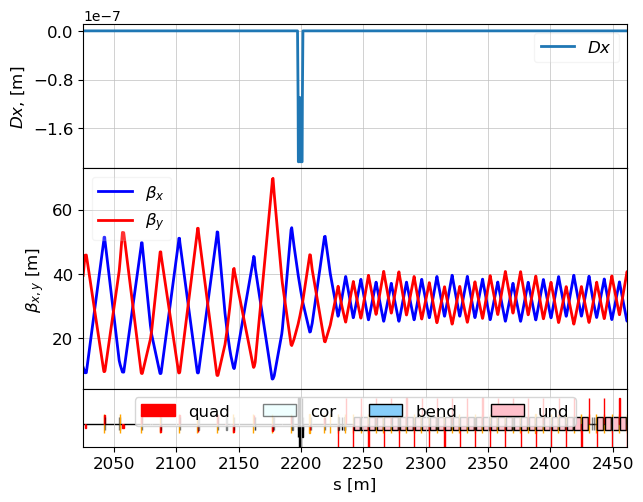

In [2]:
lat = MagneticLattice(sase1.cell)

tws = twiss(lat, sase1.tws0)
plot_opt_func(lat, tws)
plt.show()

## 3. Selecting Quadrupoles and BPMs


In [3]:
quads = []
bpms = []
for e in lat.sequence:
    if isinstance(e, Quadrupole):
        if ".SA1" in e.id:
            quads.append(e)
    if isinstance(e, Monitor):
        if ".SA1" in e.id :
            bpms.append(e)
print(f"n bpms = {len(bpms)}")
print(f"n quads = {len(quads)}")


n bpms = 37
n quads = 37


## 4. Response Matrices for Multiple Energies

In a typical BBA, beam energy is varied while quadrupole currents remain fixed.
This allows one to separate BPM offsets (energy-independent) from quadrupole kicks (∝ 1/E).

In simulation, we instead fix the lattice energy and scale quadrupole strengths inversely with energy:

$$
k_1(E) = k_{1,\text{ref}}\frac{E_{\text{ref}}}{E},
$$

so that for lower energies, the same quadrupole current produces a stronger focusing effect — exactly as in the real accelerator.


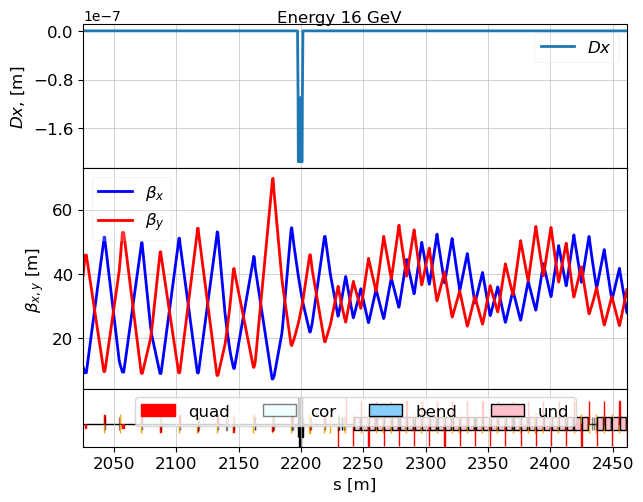

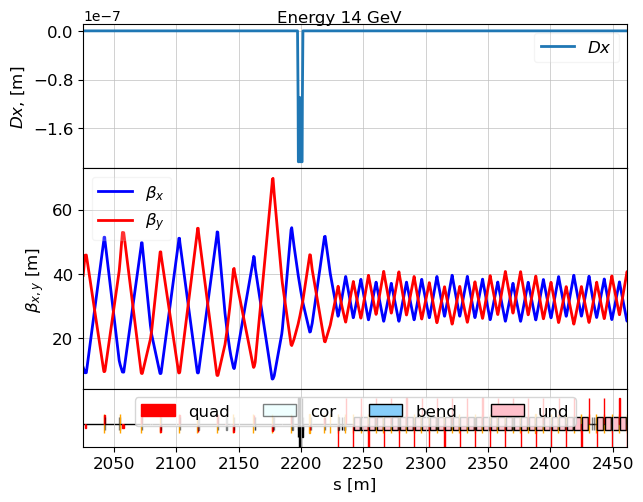

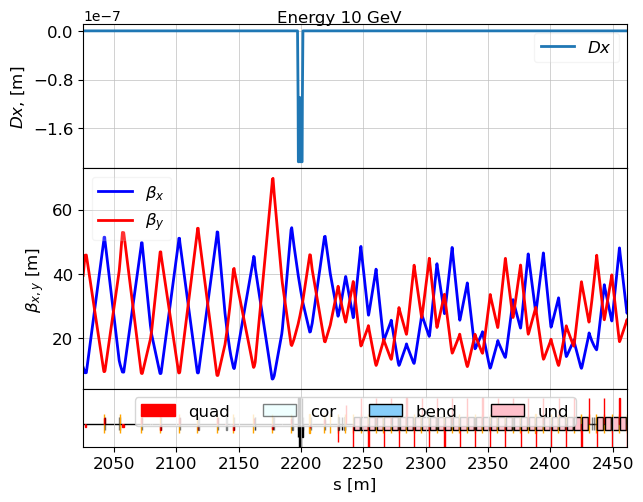

In [4]:
Eref = 14 # GeV
energies = [16, 14, 10] # GeV 
Rxs, Rys, Pxs, Pys = bba.generate_response_matrices_for_energies(lat, quads, bpms, energies, Eref, plot=True, tws0=sase1.tws0)

## 5. Building the Full System

We start from the basic relations that describe the BPM readings in the horizontal and vertical planes:

$$
\begin{aligned}
m_x &= R_x \, x_{\text{init}} + P_x \, d_x - b_x, \\
m_y &= R_y \, y_{\text{init}} + P_y \, d_y - b_y.
\end{aligned}
$$

Here:
- $ R_{x,y} $ are the **launch response matrices**,  
- $ P_{x,y} $ are the **quadrupole response matrices**,  
- $ b_{x,y} $ are the **BPM offsets**,  
- $ m_{x,y} $ are the measured BPM readings.

All these terms can be combined into a single linear system:

$$
M = A \, X,
$$

where

$$
M = 
\begin{bmatrix}
m_x \\
m_y
\end{bmatrix},
\qquad
A = 
\begin{bmatrix}
R_x & P_x & -I_{N_\text{BPM}} & 0 & 0 & 0 \\
0 & 0 & 0 & R_y & P_y & -I_{N_\text{BPM}}
\end{bmatrix},
\qquad
X =
\begin{bmatrix}
x_{\text{init}} \\[2mm]
d_x \\[2mm]
b_x \\[2mm]
y_{\text{init}} \\[2mm]
d_y \\[2mm]
b_y
\end{bmatrix}.
$$

Thus, the **full matrix $ A $** contains contributions from the launch, quadrupole, and BPM offset parts.

---

We assume that the **launch orbit** remains the same for all energy settings, meaning we need to determine only the initial beam parameters  
$ x_0, x_0' $ and $ y_0, y_0' $.  

If this assumption is not valid, the call to: 
```python
bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys])
```

must be adjusted to include additional degrees of freedom corresponding to different launch conditions.

In our example, we have
$ N_{\text{BPM}} = 37 $ and $N_{\text{quad}} = 37$.
We aim to find the BPM offsets and quadrupole offsets in both the horizontal and vertical planes.

Thus, the number of columns in the global matrix is:

$$
N_{\text{col}} = 2 \times (2 + N_{\text{BPM}} + N_{\text{quad}}) = 152,
$$

which accounts for:
* 2 planes $x$ and $y$,
* 2 launch parameters per plane $(x_0, x_0’)$, $(y_0, y_0’)$,
* $ N_{\text{BPM}} $ BPM offsets per plane,
* $ N_{\text{quad}} $ quadrupole offsets per plane.

The number of rows is given by:

$$
N_{\text{row}} = N_{\text{BPM}} \times 2 \times 3 = 222,
$$

where:
* $ N_{\text{BPM}} $ — number of BPMs,
* factor 2 — for horizontal and vertical readings,
* factor 3 — for the three energy settings used in the simulation.

In [5]:
A = bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys])

print(f"Shape A = [{A.shape}]")

Shape A = [(222, 152)]


## 6. Introducing Offsets and Simulating BPM Readings

In [6]:
# generate quads offsets
dx, dy = bba.get_random_offsets(elements=quads, sigma_x=100e-6, sigma_y=100e-6, n_sigma=3.0)
# introduce them in quadrupoles
for i, q in enumerate(quads):
    q.dx = dx[i]
    q.dy = dy[i]
    
# generate BPM offsets
bx, by = bba.get_random_offsets(elements=bpms, sigma_x=100e-6, sigma_y=100e-6, n_sigma=3.0)
#We do not need to introduce in BMPs since we have a function to read orbit which will take care of it

## 7. Getting BPM Readings for Different Beam Energies

This step is conceptually similar to generating the response matrices.  
The function:

```python
read_bpm_trajectories_vs_energy()
```
returns the simulated BPM readings *Mx* and *My* for several beam energies —
in the same way that we obtained the response matrices for multiple energy settings.

When the argument `plot=True` is enabled, the function displays the true beam trajectories with misaligned quadrupoles.
The markers represent the BPM readings, which include additional BPM offsets.

Because of these offsets, the plotted beam trajectories (continuous lines) and the BPM readings (points) do not coincide —
illustrating the difference between the actual beam orbit and what the BPMs measure.

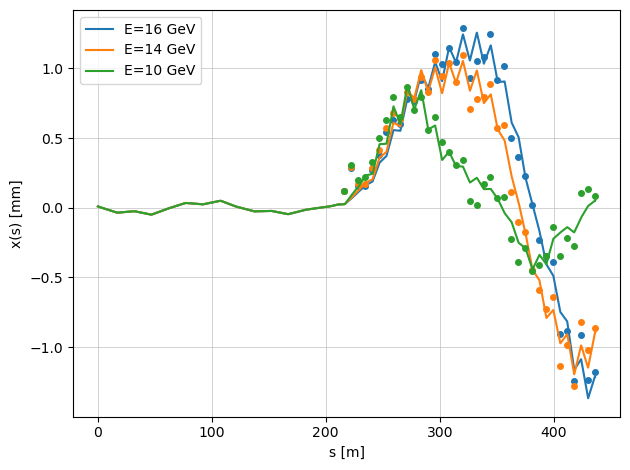

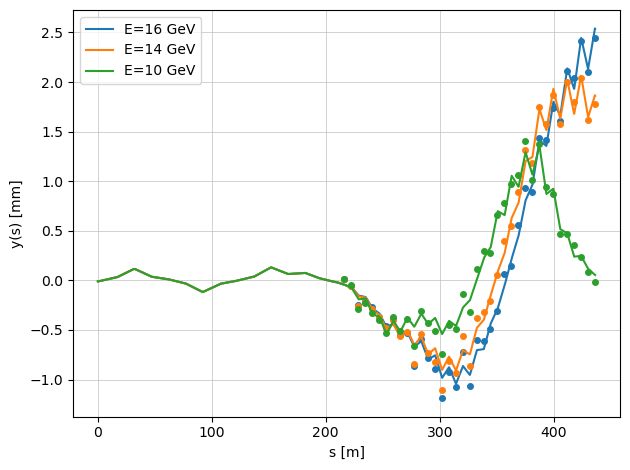

In [7]:
Xinit=(10e-6, -3e-6)
Yinit=(-10e-6, 2e-6)
Mx, My = bba.read_bpm_trajectories_vs_energy(
    lat,
    quads,
    bpms,
    energies,
    Eref,
    Xinit=Xinit, 
    Yinit=Yinit,
    bpm_offset_x=bx,
    bpm_offset_y=by,
    noise_rms=(2e-6, 2e-6), # BPM accuracy
    noise_truncated=3,
    launch_jitter = (1e-6, 0.0, 1e-6, 0.0), # launch orbit jitter in m or rad (x, x', y, y')
    launch_jitter_truncated = 3.0,
    plot=True,
)

## 8. Solving the System of Linear Equations

As discussed above, we need to solve the following linear system:

$$
M = A \, X,
$$

where:
- $ M $ — the vector of measured BPM readings (horizontal and vertical),
- $ A $ — the full response matrix built from the launch, quadrupole, and BPM offset contributions,
- $ X $ — the unknown vector containing initial beam parameters, quadrupole offsets, and BPM offsets.

To obtain $ X $, we use the **Singular Value Decomposition (SVD)** method, which allows us to compute a stable **pseudo-inverse** of the matrix $ A $.  
This approach is particularly useful when the system is overdetermined or when $ A $ is ill-conditioned.

The estimated solution can be written as:

$$
X_{\text{est}} = \text{solve\_svd}(A, M, rcutoff = 1 \times 10^{-4}),
$$

where `rcutoff` defines the relative threshold for small singular values to be ignored (regularization).

Before solving, we must first build the measurement vector $ M $, which combines all BPM readings for the different energy settings.

In [8]:
Mx = np.hstack(Mx)
My = np.hstack(My)
M = np.hstack([Mx, My])
print(f"M shape = {M.shape}")

X_est = bba.solve_svd(A=A, M=M, rcutoff=1e-4, print_spectrum=False)

Xinit_est, Yinit_est, dx_est, dy_est, bx_est, by_est = bba.extract_solution(X_est, Nquad=len(quads), Nbpm=len(bpms))

M shape = (222,)


## 9. Plot results

X:
Ground truth (1e-05, -3e-06)
Estimation [-2.97951238e-06 -6.51467272e-06]
Y:
Ground truth (-1e-05, 2e-06)
Estimation [3.42812116e-05 3.50058767e-06]


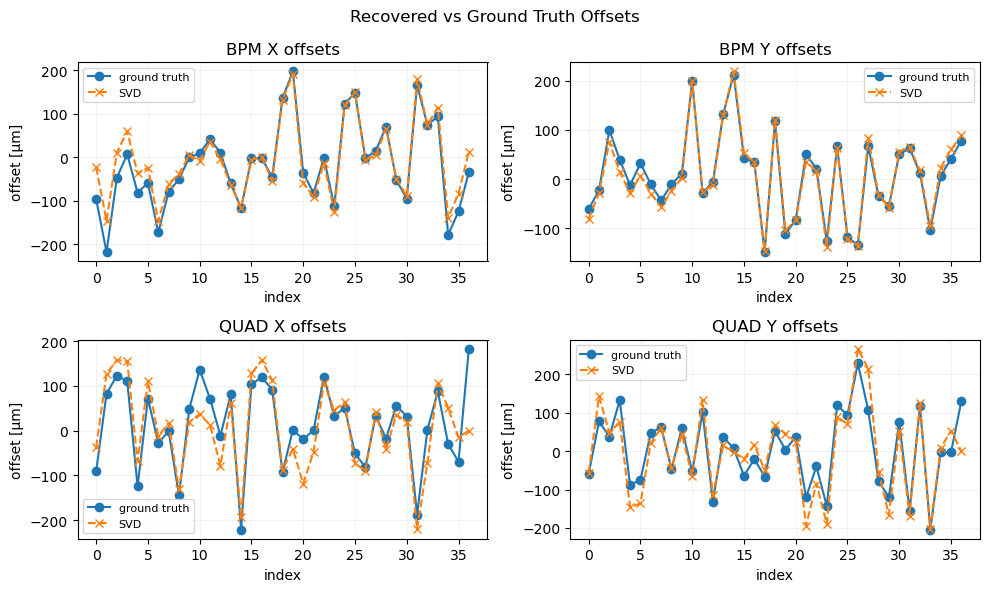

In [9]:
bpm_ids = [bpm.id for bpm in bpms]
quad_ids = [q.id for q in quads]

# ======== Plotting ========
print("X:")
print(f"Ground truth {Xinit}" )
print(f"Estimation {Xinit_est}" )
print("Y:")
print(f"Ground truth {Yinit}" )
print(f"Estimation {Yinit_est}" )
fig, axs = plt.subplots(2, 2, figsize=(10, 6), tight_layout=True)
axs = axs.ravel()

def plot_offsets(ax, gt, est1, ids, title, est2=None, label1="SVD", label2=None):
    ax.plot(gt*1e6, "o-", label="ground truth")
    ax.plot(est1*1e6, "x--", label=label1)
    if est2 is not None:
        ax.plot(svd_curve*1e6, "s:", label=label2)
    ax.set_title(title)
    ax.set_xlabel("index")
    ax.set_ylabel("offset [µm]")
    if len(ids) < 20:
        ax.set_xticks(range(len(ids)))
        ax.set_xticklabels(ids, rotation=90, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plot_offsets(axs[0], bx, bx_est, bpm_ids, "BPM X offsets", est2=None)
plot_offsets(axs[1], by, by_est, bpm_ids, "BPM Y offsets", est2=None)
plot_offsets(axs[2], dx, dx_est, quad_ids, "QUAD X offsets", est2=None)
plot_offsets(axs[3], dy, dy_est, quad_ids, "QUAD Y offsets", est2=None)

plt.suptitle("Recovered vs Ground Truth Offsets", fontsize=12)
plt.show()

# Second iteration. 
### Calculate new offsets
> **Note:**
> for the quads we need to introduce offsets manually

In [10]:
dx1 = dx - dx_est
dy1 = dy - dy_est
bx1 = bx - bx_est
by1 = by - by_est
# introduce them in quadrupoles
for i, q in enumerate(quads):
    q.dx = dx1[i]
    q.dy = dy1[i]

### Read BMPs 
here we need to introduce new bpm offsets

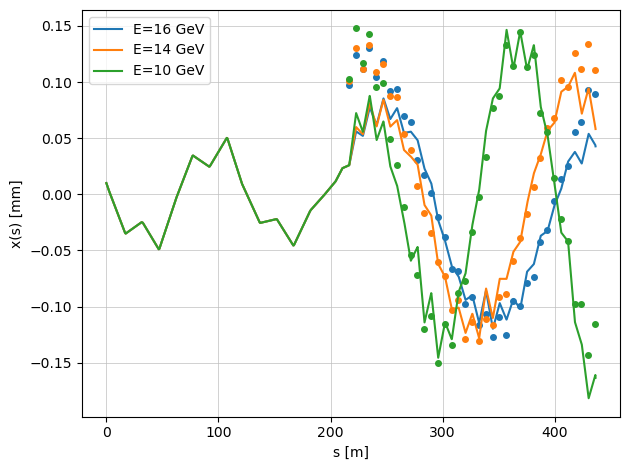

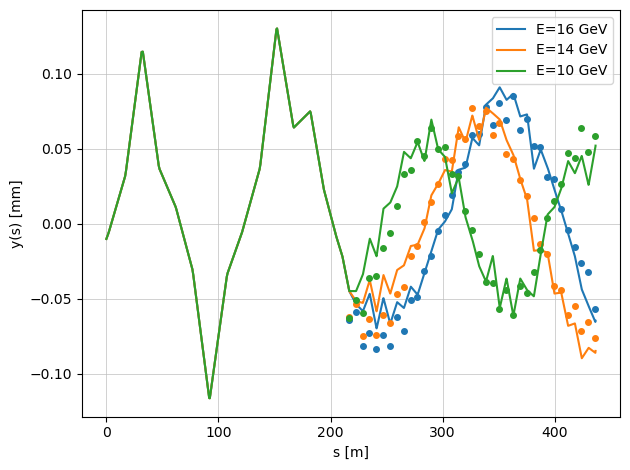

In [11]:
Mx, My = bba.read_bpm_trajectories_vs_energy(
    lat,
    quads,
    bpms,
    energies,
    Eref,
    Xinit=Xinit, 
    Yinit=Yinit,
    bpm_offset_x=bx1,
    bpm_offset_y=by1,
    noise_rms=(2e-6, 2e-6), # BPM accuracy
    noise_truncated=3,
    launch_jitter = (1e-6, 0.0, 1e-6, 0.0), # launch orbit jitter in m or rad (x, x', y, y')
    launch_jitter_truncated = 3.0,
    plot=True,
)

### Find solution

In [21]:
Mx = np.hstack(Mx)
My = np.hstack(My)
M = np.hstack([Mx, My])
print(f"M shape = {M.shape}")

X_est = bba.solve_svd(A=A, M=M, rcutoff=1e-5, print_spectrum=False)

Xinit_est, Yinit_est, dx_est, dy_est, bx_est, by_est = bba.extract_solution(X_est, Nquad=len(quads), Nbpm=len(bpms))

M shape = (222,)


### Plot results

X:
Ground truth (1e-05, -3e-06)
Estimation [ 1.12681765e-05 -3.53292306e-06]
Y:
Ground truth (-1e-05, 2e-06)
Estimation [-6.18862881e-05  7.69014895e-08]


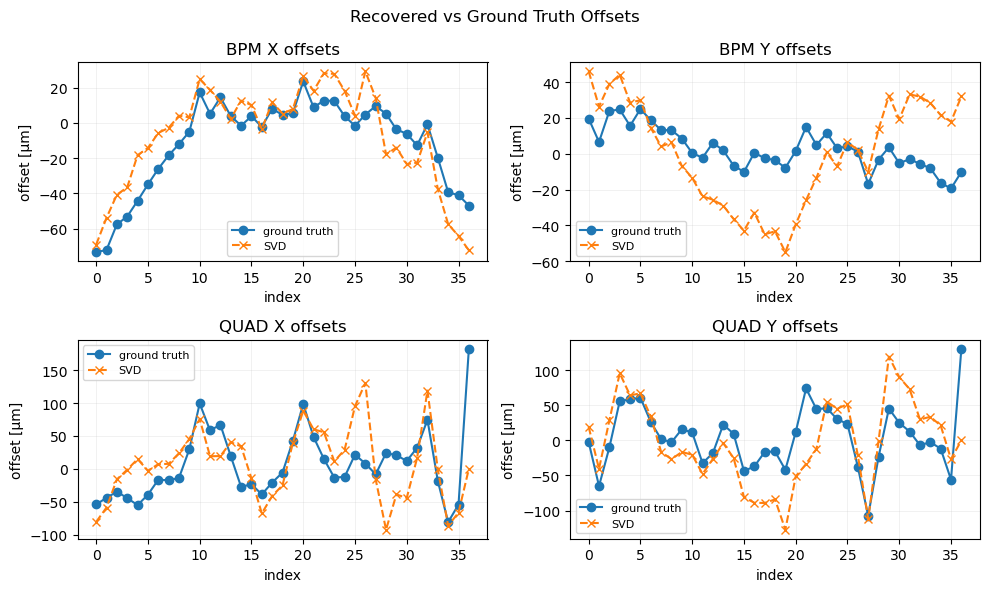

In [22]:
bpm_ids = [bpm.id for bpm in bpms]
quad_ids = [q.id for q in quads]

# ======== Plotting ========
print("X:")
print(f"Ground truth {Xinit}" )
print(f"Estimation {Xinit_est}" )
print("Y:")
print(f"Ground truth {Yinit}" )
print(f"Estimation {Yinit_est}" )
fig, axs = plt.subplots(2, 2, figsize=(10, 6), tight_layout=True)
axs = axs.ravel()


plot_offsets(axs[0], bx1, bx_est, bpm_ids, "BPM X offsets", est2=None)
plot_offsets(axs[1], by1, by_est, bpm_ids, "BPM Y offsets", est2=None)
plot_offsets(axs[2], dx1, dx_est, quad_ids, "QUAD X offsets", est2=None)
plot_offsets(axs[3], dy1, dy_est, quad_ids, "QUAD Y offsets", est2=None)

plt.suptitle("Recovered vs Ground Truth Offsets", fontsize=12)
plt.show()